Loading pandas, matplotlib, and seaborn, and setting a default style and figure size so every chart below looks consistent.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

Reading in the two cleaned CSVs produced by the data cleaning notebook.

In [3]:
main = pd.read_csv("data/cleaned/main.csv")
sales_target = pd.read_csv("data/cleaned/sales_target.csv")

Converting "Order MOnth" and "Month" from string to datetime 

In [37]:
main['Order Month'] = pd.to_datetime(main['Order Month'])
sales_target['Month'] = pd.to_datetime(sales_target['Month'])

Quick look at the merged main table to confirm it loaded correctly.

In [4]:
main.head()

,Unnamed: 0,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,Order Month
0,0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,1275.0,-1148.0,7,Furniture,Bookcases,2018-04-01
1,1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,66.0,-12.0,5,Clothing,Stole,2018-04-01
2,2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,8.0,-2.0,3,Clothing,Hankerchief,2018-04-01
3,3,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,80.0,-56.0,4,Electronics,Electronic Games,2018-04-01
4,4,B-25602,2018-04-01,Pearl,Maharashtra,Pune,168.0,-111.0,2,Electronics,Phones,2018-04-01


monthly revenue and profit over time


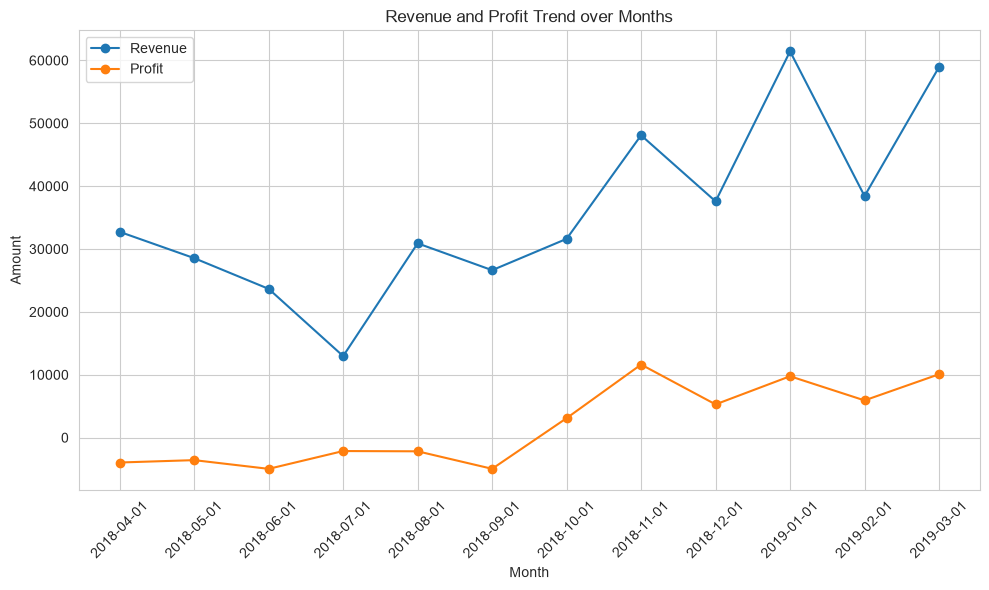

In [5]:
monthly = main.groupby('Order Month')[['Amount','Profit']].sum().reset_index()

fig, ax = plt.subplots(figsize = (10,6))
ax.plot(monthly['Order Month'],monthly['Amount'],marker = 'o', label = 'Revenue' )
ax.plot(monthly['Order Month'],monthly['Profit'],marker = 'o', label = 'Profit' )
ax.set_title('Revenue and Profit Trend over Months')
ax.set_ylabel('Amount')
ax.set_xlabel('Month')
ax.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


Total revenue broken down by Category, shown as a bar chart.

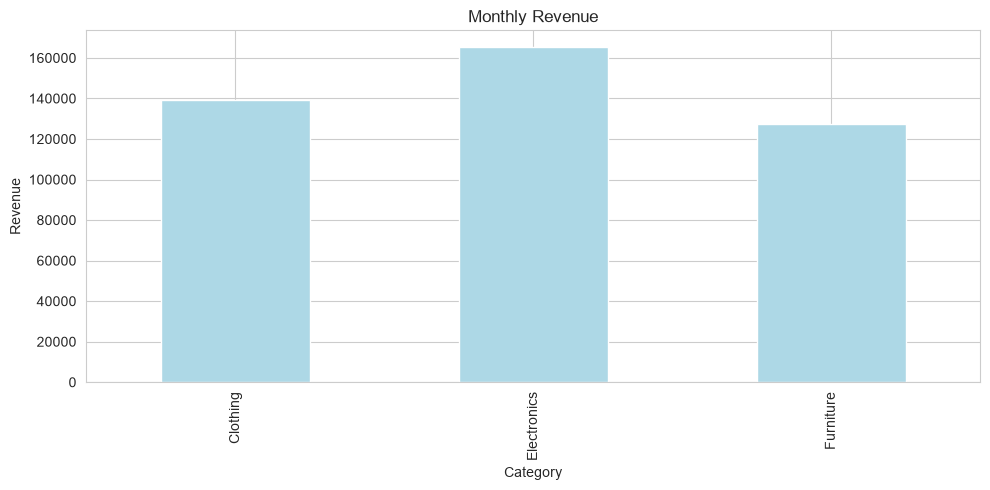

In [6]:
monthly = main.groupby('Category')['Amount'].sum() 
fig, ax = plt.subplots()
monthly.plot(kind='bar', ax=ax, color = 'lightblue')
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()


Total profit by Sub-Category

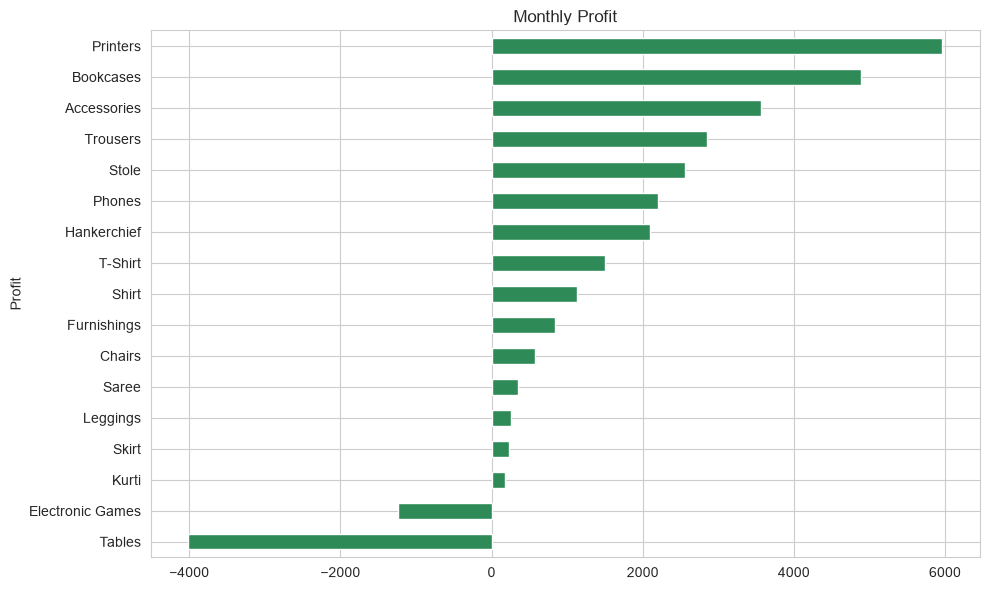

In [7]:
monthly = main.groupby('Sub-Category')['Profit'].sum().sort_values()
fig, ax = plt.subplots(figsize = (10,6))
monthly.plot(kind='barh', ax=ax, color = 'seagreen')
ax.set_title('Monthly Profit')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()


Profit margin per Sub-Category (Amount divided by Profit, as a percentage), sorted low to high.

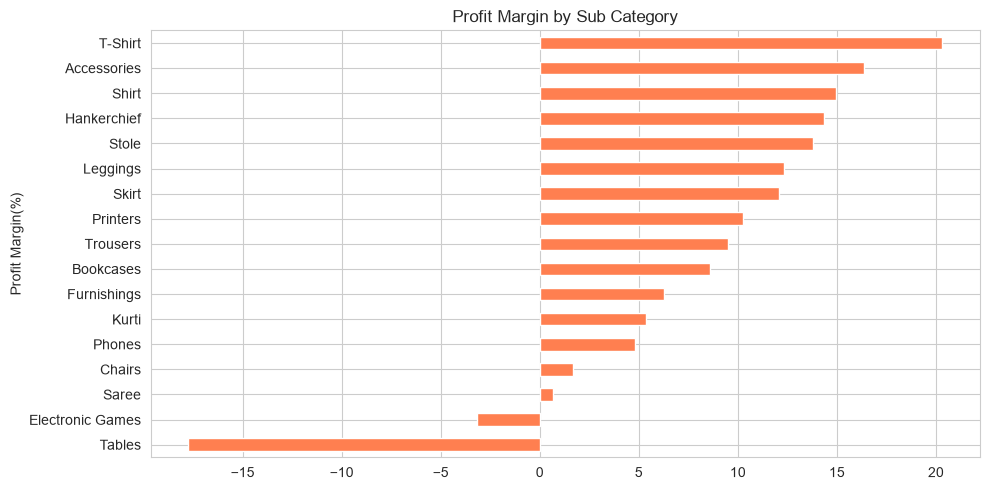

In [8]:
margin = main.groupby('Sub-Category').apply(
    lambda x: x['Profit'].sum() / x['Amount'].sum() * 100
).sort_values()

fig, ax = plt.subplots()
margin.plot(kind='barh',ax = ax, color = 'coral')
ax.set_title('Profit Margin by Sub Category')
ax.set_ylabel('Profit Margin(%)')
plt.tight_layout()
plt.show()

Scatter plot of Quantity against Profit, with a line at zero, to see whether higher quantity orders tend to be more or less profitable.

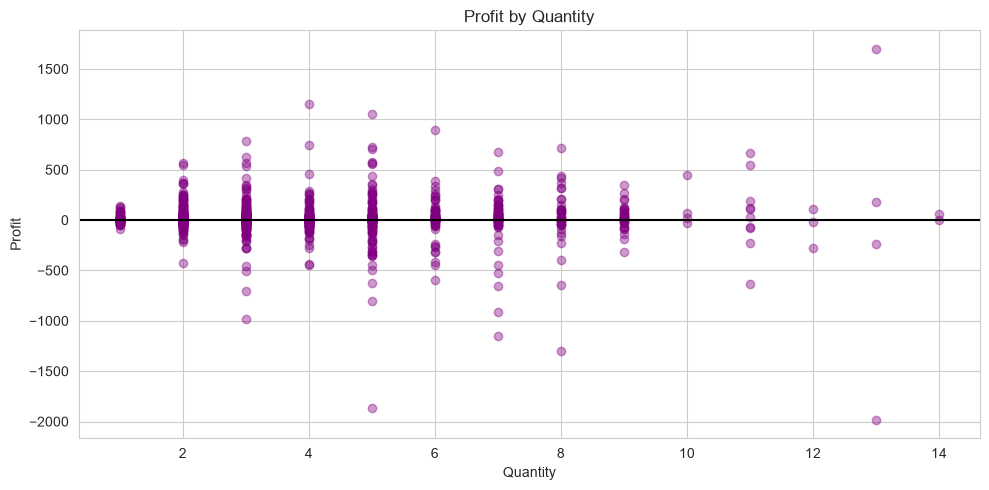

In [9]:
fig, ax = plt.subplots()
ax.scatter(x= main['Quantity'], y=main['Profit'], alpha=0.4, color = 'purple')
ax.axhline(0,color = 'black')
ax.set_title('Profit by Quantity')
ax.set_xlabel('Quantity')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

Isolating the loss-making order lines (negative profit),then charting which categories carry the most loss.

Loss-making order lines: 503 out of 1500 (33.5%)


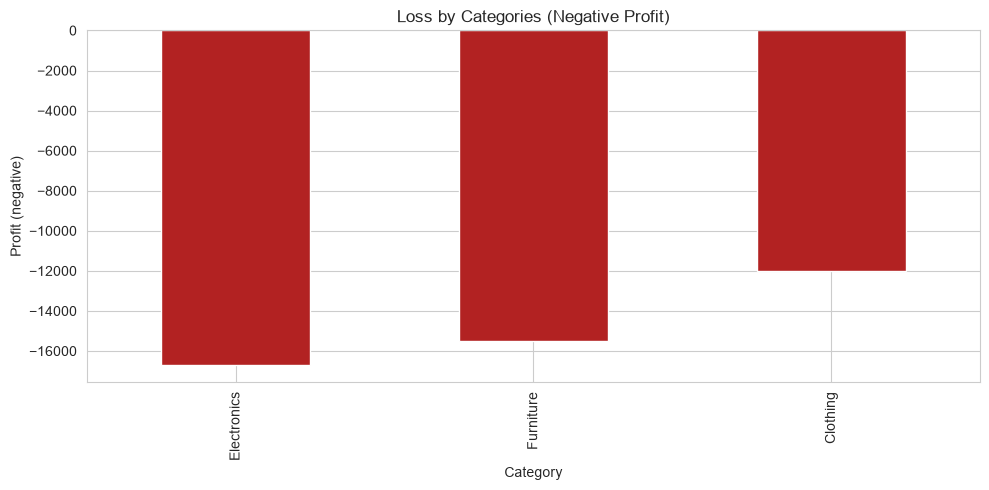

In [10]:
loss_making_orders = main[main['Profit']< 0]
print(f"Loss-making order lines: {len(loss_making_orders)} out of {len(main)} "
      f"({len(loss_making_orders)/len(main)*100:.1f}%)")

loss_by_cat = loss_making_orders.groupby('Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots()
loss_by_cat.plot(kind= 'bar', ax = ax, color = 'firebrick')
ax.set_title('Loss by Categories (Negative Profit)')
ax.set_ylabel('Profit (negative)')
plt.tight_layout()
plt.show()

Top 10 customers ranked by total revenue.

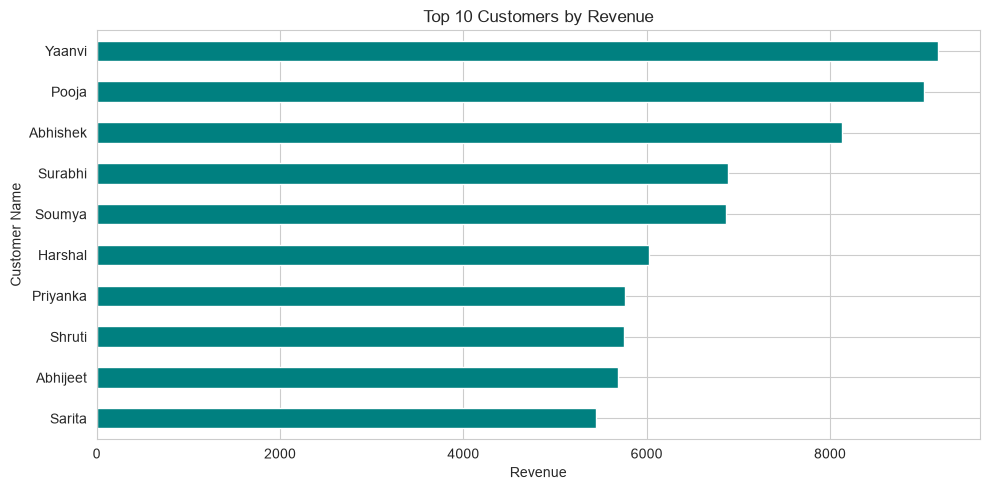

In [11]:
top_10_customers = main.groupby('CustomerName')['Amount'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_10_customers.plot(kind= 'barh', ax=ax, color = 'teal')
ax.set_title('Top 10 Customers by Revenue')
ax.invert_yaxis()
ax.set_ylabel('Customer Name')
ax.set_xlabel('Revenue')
plt.tight_layout()
plt.show()

Checking how many customers place more than one order — this prints the repeat-customer percentage and plots the distribution of order counts.

Repeact Customer are only 31.0% of total


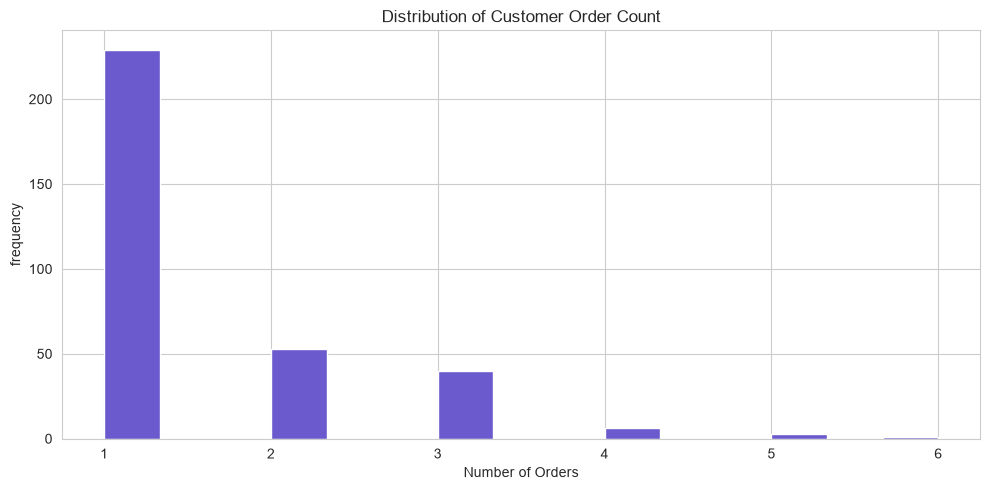

In [12]:
order_count = main.groupby('CustomerName')['Order ID'].nunique()
repeat_cus_pct = (order_count>1).mean() * 100
print(f"Repeact Customer are only {repeat_cus_pct:.1f}% of total")

fig, ax = plt.subplots()
order_count.plot(kind='hist', bins = 15, ax=ax , color = 'slateblue')
ax.set_title('Distribution of Customer Order Count')
ax.set_ylabel('frequency')
ax.set_xlabel('Number of Orders')
plt.tight_layout()
plt.show()

Top 10 states by revenue, both as a bar chart and as a table with Amount and Profit side by side.

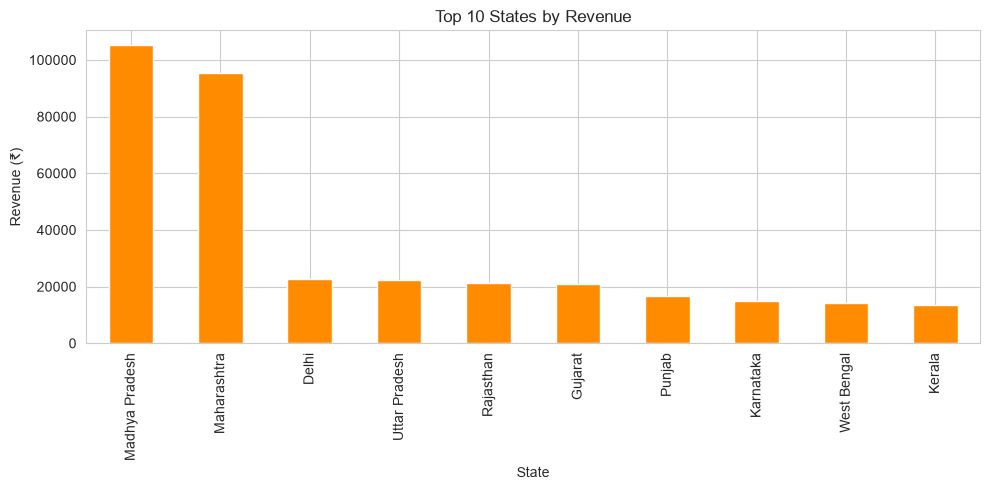

,Amount,Profit
State,,
Madhya Pradesh,105140.0,5551.0
Maharashtra,95348.0,6176.0
Delhi,22531.0,2987.0
Uttar Pradesh,22359.0,3237.0
Rajasthan,21149.0,1257.0
Gujarat,21058.0,465.0
Punjab,16786.0,-609.0
Karnataka,15058.0,645.0
West Bengal,14086.0,2500.0


In [13]:
state_perf = main.groupby("State")[["Amount", "Profit"]].sum().sort_values("Amount", ascending=False).head(10)

fig, ax = plt.subplots()
state_perf["Amount"].plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Top 10 States by Revenue")
ax.set_ylabel("Revenue (₹)")
plt.tight_layout()
plt.show()

state_perf

Creating a new table by Merging both Tables(main, sales target)

In [25]:
monthly_actual = main.groupby(['Order Month','Category'])['Amount'].sum().reset_index()
monthly_actual = monthly_actual.rename(columns={'Amount': 'Actual'})

actual_vs_target = pd.merge(monthly_actual,
                            sales_target[['Month', 'Category', 'Target']],
                            left_on=['Order Month', 'Category'],
                            right_on=['Month', 'Category'],
                            how='inner')
actual_vs_target['Achievement %'] = (actual_vs_target['Actual']/actual_vs_target['Target']*100).round(2)
actual_vs_target['Status']= actual_vs_target['Achievement %'].apply(lambda x: 'Hit' if x>= 100 else 'Miss')


actual_vs_target.head()

,Order Month,Category,Actual,Month,Target,Achievement %,Status
0,2018-04-01,Clothing,13478.0,2018-04-01,12000.0,112.32,Hit
1,2018-04-01,Electronics,11127.0,2018-04-01,9000.0,123.63,Hit
2,2018-04-01,Furniture,8121.0,2018-04-01,10400.0,78.09,Miss
3,2018-05-01,Clothing,9518.0,2018-05-01,12000.0,79.32,Miss
4,2018-05-01,Electronics,12807.0,2018-05-01,9000.0,142.30,Hit


Comparing the Actual Amount with Targeted Amount by categories

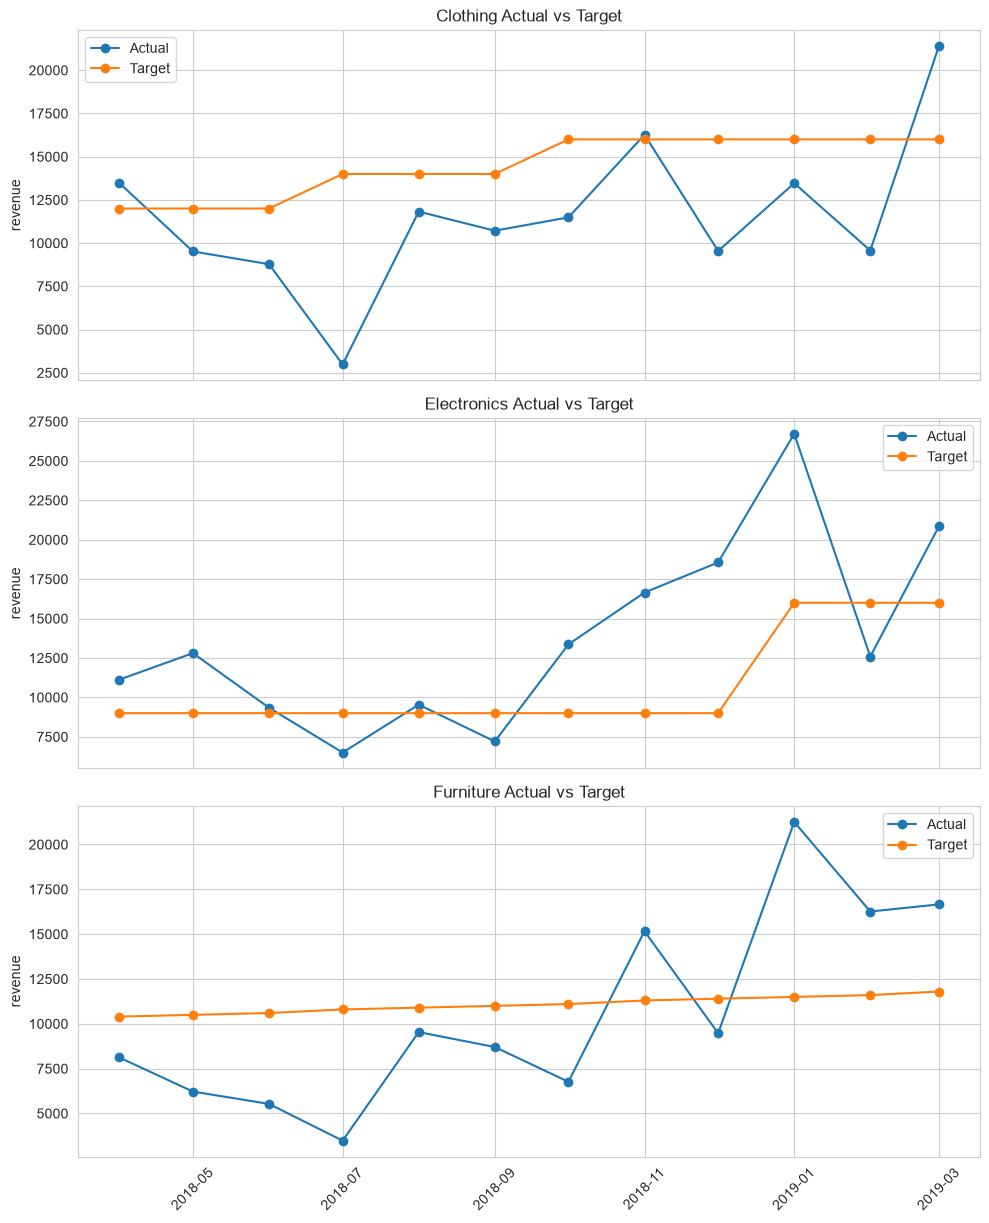

In [33]:
categories = actual_vs_target['Category'].unique()
fig, axes = plt.subplots(len(categories),1, figsize = (10, 4 * len(categories)), sharex = True)

for ax, cat in zip(axes, categories):
    data = actual_vs_target[actual_vs_target['Category'] == cat].sort_values('Order Month')
    ax.plot(data['Order Month'], data['Actual'], label = 'Actual', marker = 'o')
    ax.plot(data['Order Month'], data['Target'], label = 'Target', marker = 'o', linestyle = '-')
    ax.set_title(f'{cat} Actual vs Target')
    ax.set_ylabel('revenue')
    ax.legend()

plt.tight_layout()
plt.xticks(rotation = 45)
plt.show()

Checking how many times Target Achieved by each Category

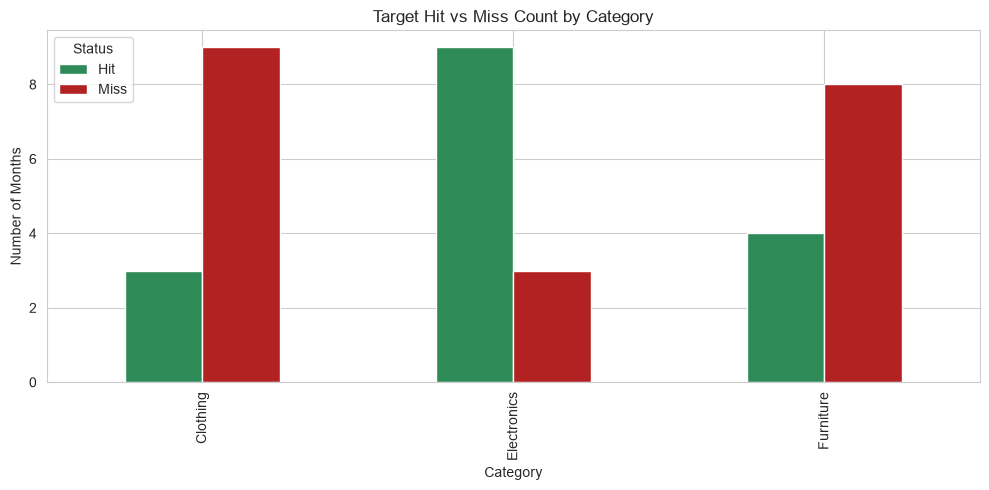

In [35]:
hit_miss_count = actual_vs_target.groupby(['Category', 'Status']).size().unstack(fill_value=0)
hit_miss_count = hit_miss_count[['Hit','Miss']]

fig, ax = plt.subplots()

hit_miss_count.plot(kind='bar', ax=ax, color=['seagreen', 'firebrick'])
ax.set_title('Target Hit vs Miss Count by Category')
ax.set_ylabel('Number of Months')
plt.tight_layout()
plt.show()

Checking average achievement percentage of each Category

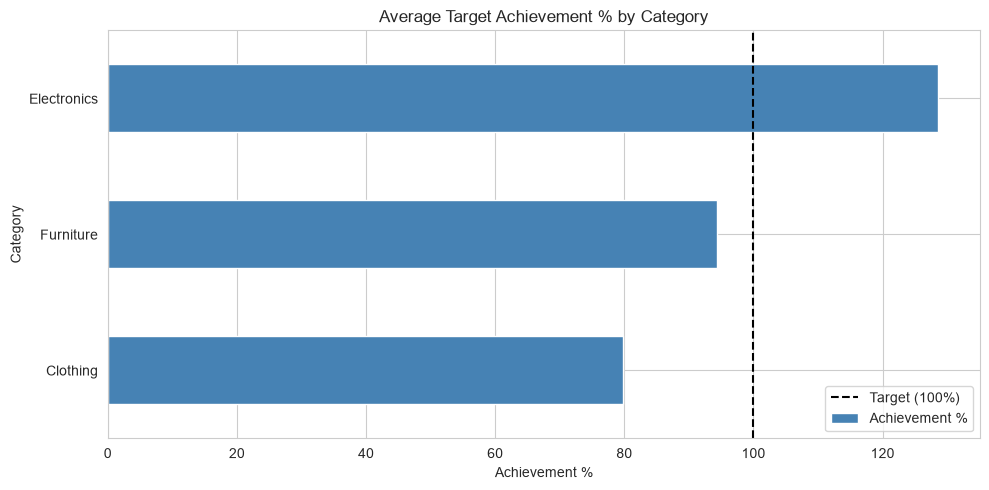

In [36]:
avg_achievement = actual_vs_target.groupby('Category')['Achievement %'].mean().sort_values()

fig, ax = plt.subplots()
avg_achievement.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(100, color='black', linestyle='--', label='Target (100%)')
ax.set_title('Average Target Achievement % by Category')
ax.set_xlabel('Achievement %')
ax.legend()
plt.tight_layout()
plt.show()